In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import get_dummies
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer
import plotly.express as px
from category_encoders import TargetEncoder
import plotly.io as pio

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_squared_error
import warnings
warnings. filterwarnings('ignore')

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df= pd.read_csv("/kaggle/input/stack-overflow/survey_results_public.csv")

In [3]:
df.shape

(73268, 79)

In [4]:
df.columns

Index(['ResponseId', 'MainBranch', 'Employment', 'RemoteWork',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType',
       'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'Country', 'Currency',
       'CompTotal', 'CompFreq', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith',
       'NEWCollabToolsWantToWorkWith', 'OpSysProfessional use',
       'OpSysPersonal use', 'VersionControlSystem', 'VCInteraction',
       'VCHostingPersonal use', 'VCHostingProfessional use',
       'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',
       'OfficeStackSyncHaveWork

In [5]:
df.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Difficult,NaN
2,3,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Friend or family member...,Technical documentation;Blogs;Programming Game...,NaN,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,40205.0
3,4,I am a developer by profession,"Employed, full-time",Fully remote,I don’t code outside of work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,215232.0
4,5,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;O...,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

In [7]:

print(df.isnull().sum())

ResponseId                 0
MainBranch                 0
Employment              1559
RemoteWork             14310
CodingActivities       14369
                       ...  
TrueFalse_2            37553
TrueFalse_3            37519
SurveyLength            2824
SurveyEase              2760
ConvertedCompYearly    35197
Length: 79, dtype: int64


In [8]:
print (df.isnull().sum().sum())

1645776


# Visualization

In [9]:
def plot_line_chart(df, column, line=""):
    if line == '':
        line = df[column].value_counts().keys()[0:20]
    data = df[column].value_counts()[0:20]
    fig=px.line(x=line,y=data)
    fig.show()
    
def plot_bar_chart(df, column, line=""):
    if line == '':
        line = df[column].value_counts().keys()[0:20]
    data = df[column].value_counts()[0:20]
    fig=px.bar(x=line,y=data)
    fig.show()
    
def plot_pie_chart(df, column, line = ''):
    if line == '':
        line = df[column].value_counts().keys()[0:20]
    data = df[column].value_counts()[0:20]
    fig=px.pie(names=line,values=data)
    fig.show()

In [10]:
plot_bar_chart(df,"Country")
plot_line_chart(df,"Country")

In [11]:
plot_bar_chart(df,"Employment")
plot_line_chart(df,"Employment")
plot_pie_chart(df,"Employment")

In [12]:
col = ['Employment','RemoteWork','EdLevel','YearsCode','DevType','OrgSize','PurchaseInfluence','Country'
    ,'MiscTechHaveWorkedWith','DatabaseHaveWorkedWith','WebframeHaveWorkedWith','ToolsTechHaveWorkedWith'
    ,'NEWCollabToolsHaveWorkedWith','OfficeStackAsyncHaveWorkedWith','Blockchain','Age','SOComm','Gender','Ethnicity'
    ,'MentalHealth','Accessibility','TBranch','ICorPM','WorkExp','Knowledge_1','Frequency_1','TimeSearching',
       'TimeAnswering','Onboarding','ProfessionalTech']

In [13]:
for c in col:
    print(c, ":", df[c].nunique())

Employment : 103
RemoteWork : 3
EdLevel : 9
YearsCode : 52
DevType : 9984
OrgSize : 10
PurchaseInfluence : 3
Country : 180
MiscTechHaveWorkedWith : 4205
DatabaseHaveWorkedWith : 4223
WebframeHaveWorkedWith : 8259
ToolsTechHaveWorkedWith : 951
NEWCollabToolsHaveWorkedWith : 15063
OfficeStackAsyncHaveWorkedWith : 1085
Blockchain : 6
Age : 8
SOComm : 6
Gender : 16
Ethnicity : 1055
MentalHealth : 57
Accessibility : 27
TBranch : 2
ICorPM : 2
WorkExp : 51
Knowledge_1 : 5
Frequency_1 : 5
TimeSearching : 5
TimeAnswering : 5
Onboarding : 5
ProfessionalTech : 155


In [14]:
fig = px.box(df, x="Country", y="ConvertedCompYearly")
fig.show()

In [15]:
for f in ['Employment','EdLevel','DevType','OrgSize','Country'
    ,'MiscTechHaveWorkedWith','DatabaseHaveWorkedWith','WebframeHaveWorkedWith','ToolsTechHaveWorkedWith'
    ,'NEWCollabToolsHaveWorkedWith','OfficeStackAsyncHaveWorkedWith','Age','SOComm','Gender','Ethnicity'
    ,'MentalHealth','Accessibility','TimeSearching',
       'TimeAnswering','ProfessionalTech']:
    freq = df[f].value_counts()

    rare = freq[freq < 20].index

    df[f] = df[f].replace(
        rare,
        "Other"
    )

In [16]:
print(df["ConvertedCompYearly"].describe(percentiles=[0.01,0.05,0.95,0.99]))

count    3.807100e+04
mean     1.707613e+05
std      7.814132e+05
min      1.000000e+00
1%       1.340400e+03
5%       7.248000e+03
50%      6.784500e+04
95%      3.839160e+05
99%      2.161310e+06
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64


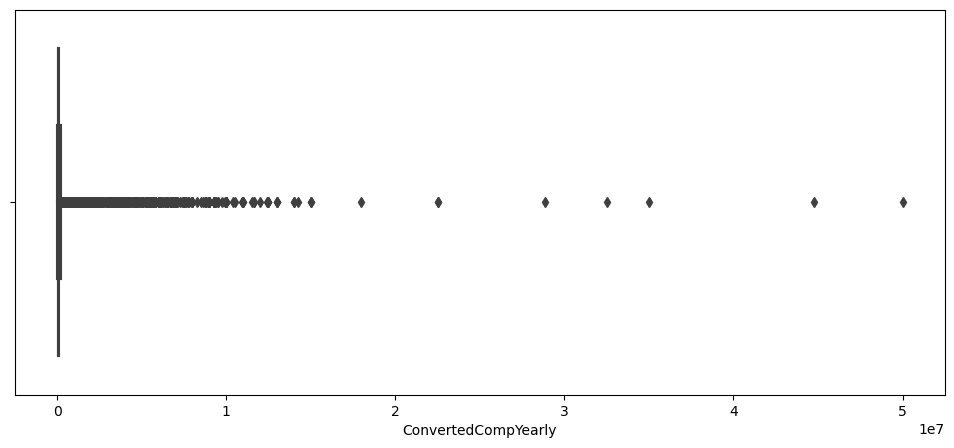

In [17]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df["ConvertedCompYearly"])
plt.show()

In [18]:
lower = df["ConvertedCompYearly"].quantile(0.01)
upper = df["ConvertedCompYearly"].quantile(0.99)

df = df[
    (df["ConvertedCompYearly"] >= lower) &
    (df["ConvertedCompYearly"] <= upper)
]

In [19]:
df1 = df[['Employment','RemoteWork','EdLevel','YearsCode','DevType','OrgSize','PurchaseInfluence','Country'
    ,'MiscTechHaveWorkedWith','DatabaseHaveWorkedWith','WebframeHaveWorkedWith','ToolsTechHaveWorkedWith'
    ,'NEWCollabToolsHaveWorkedWith','OfficeStackAsyncHaveWorkedWith','Blockchain','Age','SOComm','Gender','Ethnicity'
    ,'MentalHealth','Accessibility','TBranch','ICorPM','WorkExp','TimeSearching',
       'TimeAnswering','Onboarding','ProfessionalTech']].copy()

In [20]:
print (df1.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 37309 entries, 2 to 73121
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Employment                      37305 non-null  object 
 1   RemoteWork                      37258 non-null  object 
 2   EdLevel                         37293 non-null  object 
 3   YearsCode                       37241 non-null  object 
 4   DevType                         37234 non-null  object 
 5   OrgSize                         37280 non-null  object 
 6   PurchaseInfluence               37265 non-null  object 
 7   Country                         37309 non-null  object 
 8   MiscTechHaveWorkedWith          23755 non-null  object 
 9   DatabaseHaveWorkedWith          32653 non-null  object 
 10  WebframeHaveWorkedWith          28945 non-null  object 
 11  ToolsTechHaveWorkedWith         29941 non-null  object 
 12  NEWCollabToolsHaveWorkedWith    

In [21]:
df1['RemoteWork']  = df1['RemoteWork'].replace({'Fully remote':1,'Hybrid (some remote, some in-person)':2,'Full in-person':3})
df1['RemoteWork'] = pd.to_numeric(df1['RemoteWork'], errors='coerce')

df1['YearsCode'] = df1['YearsCode'].replace({'More than 50 years': 50,'less than 1 years': 0})
df1['YearsCode'] = pd.to_numeric(df1['YearsCode'],errors='coerce')

In [22]:
the_col_todumis = ['OrgSize','Age','EdLevel','SOComm','MentalHealth','Accessibility','TimeAnswering']

In [23]:
df1 = pd.get_dummies(
    df1,
    columns=the_col_todumis,
    dtype=np.int8
)

In [24]:
df1['PurchaseInfluence'] = df1['PurchaseInfluence'].replace({'I have some influence':1,'I have little or no influence':2,'I have a great deal of influence':3})
df1['PurchaseInfluence'] = pd.to_numeric(df1['PurchaseInfluence'], errors='coerce')
df1['Blockchain'] = df1['Blockchain'].replace({'Indifferent':0,'Favorable':1,'Very unfavorable':2,'Unfavorable':3,'Unsure':4,
                        'Very favorable':5})
df1['Blockchain'] = pd.to_numeric(df1['Blockchain'],errors='coerce')

In [25]:
df1['TBranch'] = df1['TBranch'].map({'Yes':1,'No':0})
df1['ICorPM'] = df1['ICorPM'].map({'Independent contributor':1,'People manager':2})
df1['Onboarding'] = df1['Onboarding'].map({'somewhat long':1,'Just right':2,'Somewhat short':3,'Very long':4,'very short':5})

In [26]:
x = df1.copy()
y = np.log1p(df['ConvertedCompYearly'])

In [27]:
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
multi_cols = ['DatabaseHaveWorkedWith','WebframeHaveWorkedWith','ToolsTechHaveWorkedWith','MiscTechHaveWorkedWith','DevType','NEWCollabToolsHaveWorkedWith','OfficeStackAsyncHaveWorkedWith'
]

In [29]:
for col in multi_cols:
    train_dummy = train_x[col].fillna('').str.get_dummies(sep=';')
    test_dummy = test_x[col].fillna('').str.get_dummies(sep=';')

    test_dummy = test_dummy.reindex(columns=train_dummy.columns,fill_value=0)

    train_x = train_x.drop(columns=[col])
    test_x = test_x.drop(columns=[col])

    train_x = pd.concat([train_x, train_dummy], axis=1)
    test_x = pd.concat([test_x, test_dummy], axis=1)

In [30]:
target_cols = ['Country','Employment','ProfessionalTech','Gender','Ethnicity']

In [31]:
target_cols = ['Country','Employment','ProfessionalTech','Gender','Ethnicity']

In [32]:
te = TargetEncoder(
    cols=target_cols,
    smoothing=50
)

In [33]:
train_x[target_cols] = te.fit_transform(
    train_x[target_cols],train_y)

test_x[target_cols] = te.transform(test_x[target_cols])

In [34]:
print(train_x.isnull().sum().sum())
print(test_x.isnull().sum().sum())

45246
11077


In [35]:
mapping = {
    '15-30 minutes a day': 1,
    '30-60 minutes a day': 2,
    '30-60 minutes a day': 3,
    'Less than 15 minutes a day': 4,
    'Over 120 minutes a day': 5
}

train_x['TimeSearching'] = train_x['TimeSearching'].map(mapping)
test_x['TimeSearching'] = test_x['TimeSearching'].map(mapping)

In [36]:
imp = SimpleImputer(strategy='most_frequent')

train_x = pd.DataFrame(
    imp.fit_transform(train_x),
    columns=train_x.columns,
    index=train_x.index
)

test_x = pd.DataFrame(
    imp.transform(test_x),
    columns=test_x.columns,
    index=test_x.index
)

In [37]:
sc = StandardScaler()
train_x_scal = sc.fit_transform(train_x)
test_x_scal = sc.transform(test_x)

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression(n_jobs=-1)
lr.fit(train_x_scal, train_y)
y_pred = lr.predict(test_x_scal)
pred_Y = lr.predict(train_x_scal)
print(r2_score(train_y,pred_Y))
print(r2_score(test_y,y_pred))

0.5603206900464068
0.5626408792426776
